# Dataset Handling Examples
This notebook shows how to use the classes in `utils/` to load metadata, filter trials/segments, and inspect videos, responses, neurons, and behavioral signals.

Run the cells from top to bottom so the `DataSet` object and required paths are initialized before data-loading examples.

In [28]:
import numpy as np
import os
import matplotlib.pyplot as plt
from pathlib import Path

from ssdatam.dataset import DataSet

Set the paths used to access data and metadata.

In [29]:
repo_root = Path.cwd().parent

# path to the folder with the data as downloaded
folder_data = repo_root / 'data/'

# path to the metadata folder
folder_meta = repo_root / 'metadata'


Initialize a `DataSet` object to handle the full dataset.

This object allows you to:
- manage metadata
- load data
- use visualization utilities
- generate metadata when it is missing

Note: 
If the dataset has already been checked, you can skip the data, and metadata integrity checks by setting check to False when initializing the DataSet. This will speed up the loading of the dataset, but it will assume that the data is valid and the metadata is valid for existing folders and invalid for missing folders. 
You can also set check_data and check_metadata to False separately (keeping check=True), if you want to skip only one of the two checks.

Note: 
By default the metadata per trials is taken from the CSV file in folder_metadata / recording / trials.
Metadata can be taken from the json files setting trials_metadata_file_type='json'

In [30]:
# initialize the object to handle the dataset
ds = DataSet(folder_data, folder_metadata=folder_meta, verbose=True, check=False)


Initializing DataSet -------------------------------------------------------------------------------

Data integrity check skipped -----------------------------------------------------------------------
 > If you want to check it, set check and check_data to True when initializing the DataSet.
 > Data is assumed to be valid. Misbehavior may occur if the data is corrupted.

Metadata integrity check skipped -------------------------------------------------------------------
 > If you want to check it, set check and check_metadata to True when initializing the DataSet.
 > Metadata will be assumed to be valid for existing folders and invalid for missing folders.

Loading neurons metadata ---------------------------------------------------------------------------
 > Loading neurons for recording dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce from metadata
 > Loading neurons for recording dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20 from metadata
 > Loading neurons for 

In [31]:
print(ds)

The dataset contains 10 recordings:
  - dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce with 7671 neurons recorded, 714 trials, and 403 samples per trial
  - dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20 with 8202 neurons recorded, 711 trials, and 326 samples per trial
  - dynamic29623-4-9-Video-9b4f6a1a067fe51e15306b9628efea20 with 7908 neurons recorded, 682 trials, and 325 samples per trial
  - dynamic29515-10-12-Video-9b4f6a1a067fe51e15306b9628efea20 with 7863 neurons recorded, 711 trials, and 324 samples per trial
  - dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce with 7440 neurons recorded, 720 trials, and 324 samples per trial
  - dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce with 7495 neurons recorded, 723 trials, and 315 samples per trial
  - dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20 with 8122 neurons recorded, 712 trials, and 414 samples per trial
  - dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce with 7928 neuron

## Load Metadata

### Load Metadata for Trials

A DataFrame with trial metadata can be loaded with:
- `get_trials_metadata()` — loads metadata from `folder_metadata`

It loads metadata and store it in `DataSet.trials_df`.

In [32]:
# load a dataframe with all trials metadata
ds.get_trials_metadata()
ds.trials_df


Creating trials metadata DataFrame from meta-trials files per recording ----------------------------


,recording,label,video_ID,trial,trial_type,valid_frames,valid_trial,valid_frames_video,valid_frames_response,valid_response
0,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,PinkNoise,v391908,203,final_test_bonus,324,True,324,324,True
1,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalVideo,v191606,193,live_test_main,300,True,300,300,True
2,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalVideo,v259199,459,train,300,True,300,300,True
3,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalVideo,v317244,19,live_test_main,300,True,300,300,True
4,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalVideo,v531838,289,train,300,True,300,300,True
...,...,...,...,...,...,...,...,...,...,...
7140,dynamic29234-6-9-Video-8744edeac3b4d1ce16b6809...,NaturalVideo,v241864,286,train,300,True,300,300,True
7141,dynamic29234-6-9-Video-8744edeac3b4d1ce16b6809...,NaturalVideo,v000453,594,train,300,True,300,300,True
7142,dynamic29234-6-9-Video-8744edeac3b4d1ce16b6809...,NaturalVideo,v420262,414,train,300,True,300,300,True
7143,dynamic29234-6-9-Video-8744edeac3b4d1ce16b6809...,RandomDots,v605412,287,live_test_bonus,240,True,240,240,True


### Load Metadata for Segments

A DataFrame with video-segment metadata can be loaded with:
- `get_segments_meta()` — loads metadata from `folder_metadata`

This method stores metadata in `DataSet.segments_df`.

In [33]:
# load a dataframe with segment metadata
ds.get_segments_metadata()
ds.segments_df


Creating segments metadata DataFrame from JSON files in /home/anaflo/Documenti/MDMC/sensorium/metadata/global_meta/segments 


,segment_ID,segment_label,video_ID,video_label,recording,trial,segment_index,frame_start,frame_end
0,s130357,GaussianDot,v892982,GaussianDot,dynamic29514-2-9-Video-8744edeac3b4d1ce16b6809...,700,24,216,225
1,s130357,GaussianDot,v892982,GaussianDot,dynamic29514-2-9-Video-8744edeac3b4d1ce16b6809...,724,24,216,225
2,s130357,GaussianDot,v892982,GaussianDot,dynamic29514-2-9-Video-8744edeac3b4d1ce16b6809...,619,24,216,225
3,s130357,GaussianDot,v892982,GaussianDot,dynamic29514-2-9-Video-8744edeac3b4d1ce16b6809...,347,24,216,225
4,s130357,GaussianDot,v892982,GaussianDot,dynamic29514-2-9-Video-8744edeac3b4d1ce16b6809...,275,24,216,225
...,...,...,...,...,...,...,...,...,...
29834,s786126,NaturalImages,v609482,NaturalImages,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,689,9,147,163
29835,s786126,NaturalImages,v609482,NaturalImages,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,693,9,147,163
29836,s786126,NaturalImages,v609482,NaturalImages,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,711,9,147,163
29837,s786126,NaturalImages,v609482,NaturalImages,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,681,9,147,163


## Filtering Data

Filtering can be applied based on any of the columns of the DataFrames to filter. It supports:
- values or lists of values
- string operation ["contains", "startswith", "endswith"]. Usage: `filter_trials(columnA__contains="test")`
- operators (gt, lt, ge, le, ne, eq). Usage: `filter_trials(columnA__gt=5)`


### By Trial Properties

Method `filter_trials()` returns a filtered version of `DataSet.trials_df`.
Filtering can be applied based on any of the columns of the trials_df DataFrame.

Note: `DataSet.trials_df` contains only basic metadata (recording, trial).
Call `get_trials_metadata_per_trials()` or `get_trials_metadata()` before filtering trials to get extra metadata.

### By Segment Properties

Method `filter_segments()` returns a filtered version of `DataSet.segments_df`.
Filtering can be applied based on any of the columns of the segments_df DataFrame.

Note: `DataSet.segments_df` is not loaded during DataSet initialization.
Call `get_segments_metadata()` before filtering segments to load the segments metadata.


In [34]:
# get the trials for one recording and one label
filtered_trials_df = ds.filter_trials(recording='dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce', label='GaussianDot')

In [35]:
# get the trials for one recording and two possible IDs
filtered_trials_df = ds.filter_trials(recording='dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce', video_ID=['v904282','v664518'])

In [36]:
# filter segments by ID
filtered_segments_df = ds.filter_segments(segment_ID='s760623')

In [37]:
# filter segments by segment label
filtered_segments_df = ds.filter_segments(segment_label='Gabor')

## Loading Data

Several methods are available to load data.

Note: `DataSet.trials_df` must exist first; call `get_trials_metadata()` before loading by trial filters.

### Load a Specific Trial
You can load one video, neural response, or behavioral signal for a single trial of one recording using the following methods:  

- `load_video_by_trial(recording, trial)` — returns a `Video` object  

- `load_response_by_trial(recording, trial)` — returns a `Response` object  

- `load_behavior_by_trial(recording, trial, behavior_type='pupil')` — returns a `Pupil` object  

- `load_behavior_by_trial(recording, trial, behavior_type='gaze')` — returns a `Gaze` object   

- `load_behavior_by_trial(recording, trial, behavior_type='locomotion')` — returns a `Locomotion` object  

In [38]:
# Load for one trial the video, the response and the behavior (pupil, gaze and locomotion)
rec = 'dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce'
trial = '475'

video = ds.load_video_by_trial(rec, trial)
response = ds.load_response_by_trial(rec, trial)
pupil = ds.load_behavior_by_trial(rec, trial, behavior_type='pupil')
gaze = ds.load_behavior_by_trial(rec, trial, behavior_type='gaze')
locomotion = ds.load_behavior_by_trial(rec, trial, behavior_type='locomotion')

### Load Filtered Data
All data matching specific filters can be loaded using:

- `load_videos_by(filtering conditions)` — returns a list of `Video` objects and the filtered trial-metadata DataFrame

- `load_responses_by(filtering conditions)` — returns a list of `Response` objects and the filtered trial-metadata DataFrame

- `load_behavior_by(filtering conditions, behavior_type='pupil')` — returns a list of `Pupil` objects and the filtered trial-metadata DataFrame

- `load_behavior_by(filtering conditions, behavior_type='gaze')` — returns a list of `Gaze` objects and the filtered trial-metadata DataFrame

- `load_behavior_by(filtering conditions, behavior_type='locomotion')` — returns a list of `Locomotion` objects and the filtered trial-metadata DataFrame

In [39]:
# load the neural responses for one label and recording
responses, filtered_trials_df = ds.load_responses_by(recording='dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce', label='GaussianDot')
print(f"{len(responses)} responses found")

58 responses found


In [40]:
# load the neural responses for one video ID
responses, filtered_trials_df = ds.load_responses_by(video_ID='v892982')
print(f"{len(responses)} responses found")


20 responses found


### Load by ID

Videos and video segments can also be loaded by ID.
In this case, a representative video is chosen at random.

- `DataSet.load_video_by_id(id=videoID)` — returns a `Video` object

- `DataSet.load_segment_by_id(id=segmentID)` — returns a `VideoSegment` object

In [41]:
# load an exemplar video by ID
video = ds.load_video_by_id('v892982')

In [42]:
# load an exemplar segment by ID
segment = ds.load_segment_by_id('s063694')

## Class `Video`
The `Video` class is used to handle video data.

In [43]:
# get the videos for one recording and one label
videos, filtered_trials_df = ds.load_videos_by(recording='dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce', 
                                               label='GaussianDot', 
                                               verbose=False)
video = videos[0]

In [44]:
# Display the video clip
video.display_video_clip()

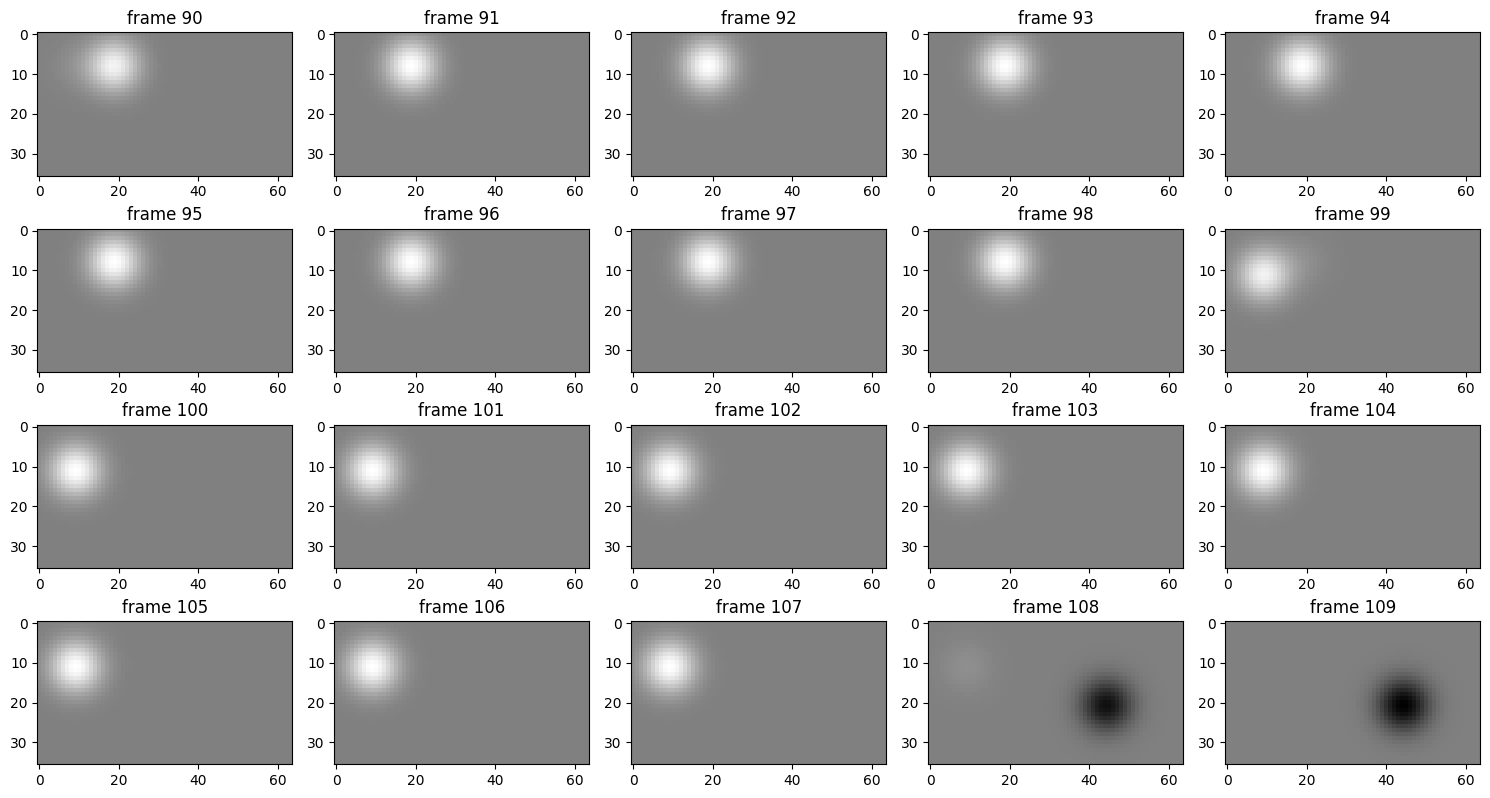

In [45]:
# Display specific frames of the video
frames_to_display = np.arange(90,110)
fig, ax = video.plot_frames(frames_to_display)

## Class `Response`
The `Response` class is used to handle neural responses for one trial.

In [46]:
# get the videos for one recording and one label
responses, filtered_trials_df = ds.load_responses_by(recording='dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce', label='GaussianDot')
response = responses[0]
print(f"- the recording of the response is: {response.recording}")
print(f"- the trial of the response is: {response.trial}")
print(f"- the number of valid frames are: {response.valid_frames}")
print(f"- the label is: {response.label}")
print(f"- the ID of the video is: {response.ID}")
print(f"- the response data has shape: {response.data.shape}")


- the recording of the response is: dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce
- the trial of the response is: 557
- the number of valid frames are: 315
- the label is: GaussianDot
- the ID of the video is: v354771
- the response data has shape: (7495, 315)


Data in `Response` can be accessed using `get_data()`:
- returns data for all neurons and valid frames
- optionally returns normalized data

In [47]:
# data not normalized
data = response.get_data() 

# data normalized by the mean (across the responses for all trials) (d - mean)/mean
data_norm_mean = response.get_data(normalization='by_mean') 

# data normalized by the standard deviation (across the responses for all trials) d/std
data_norm_std = response.get_data(normalization='by_std')


(<Figure size 800x1000 with 1 Axes>, <Axes: xlabel='samples'>)

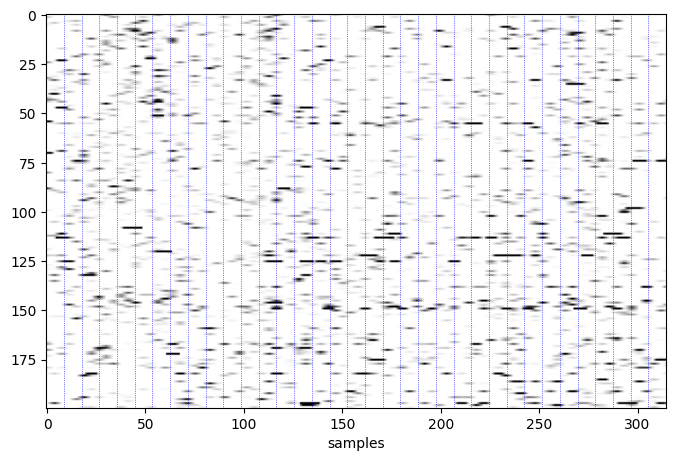

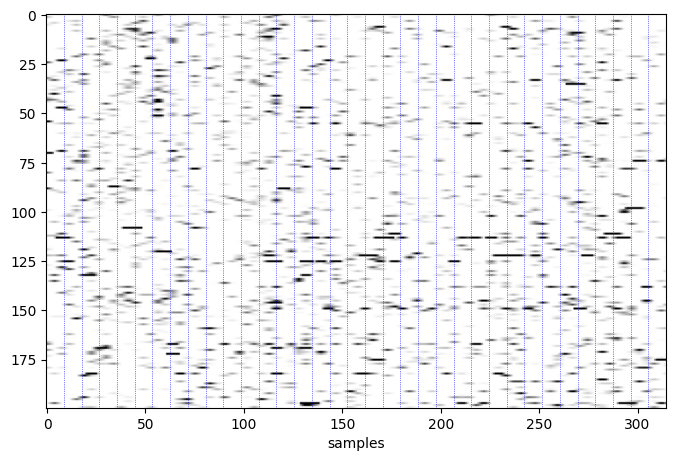

In [48]:
# plot responses as image
idx_neurosn_to_plot = np.arange(0,200)
response.plot_responses_raster(idx_neurosn_to_plot, normalization='by_std')
response.plot_responses_raster(idx_neurosn_to_plot, normalization='by_mean')

(<Figure size 800x1000 with 1 Axes>, <Axes: xlabel='samples'>)

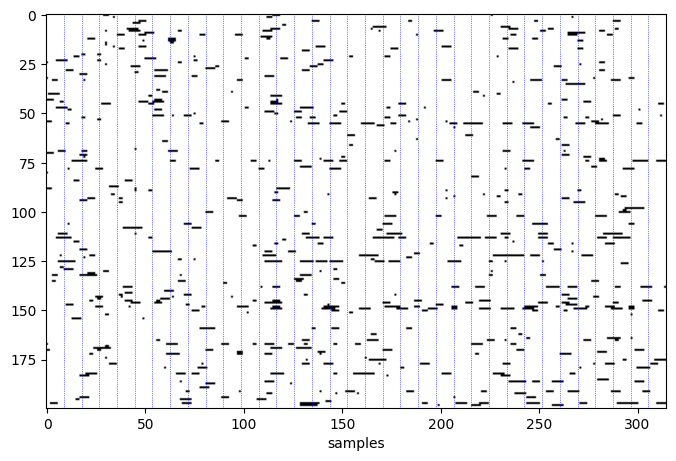

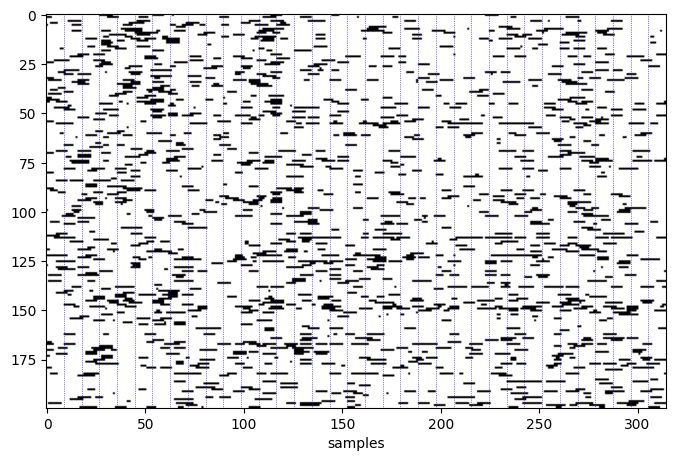

In [49]:
# plot "active" neuron responses as image. Active if define as an activity above a certain threshold (e.g. 1 std or 1 mean)
idx_neurosn_to_plot = np.arange(0,200)
response.plot_active_raster(idx_neurosn_to_plot, 1, normalization='by_std')
response.plot_active_raster(idx_neurosn_to_plot, 0, normalization='by_mean')

/home/anaflo/Documenti/MDMC/sensorium/ssdatam/responses.py:345: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


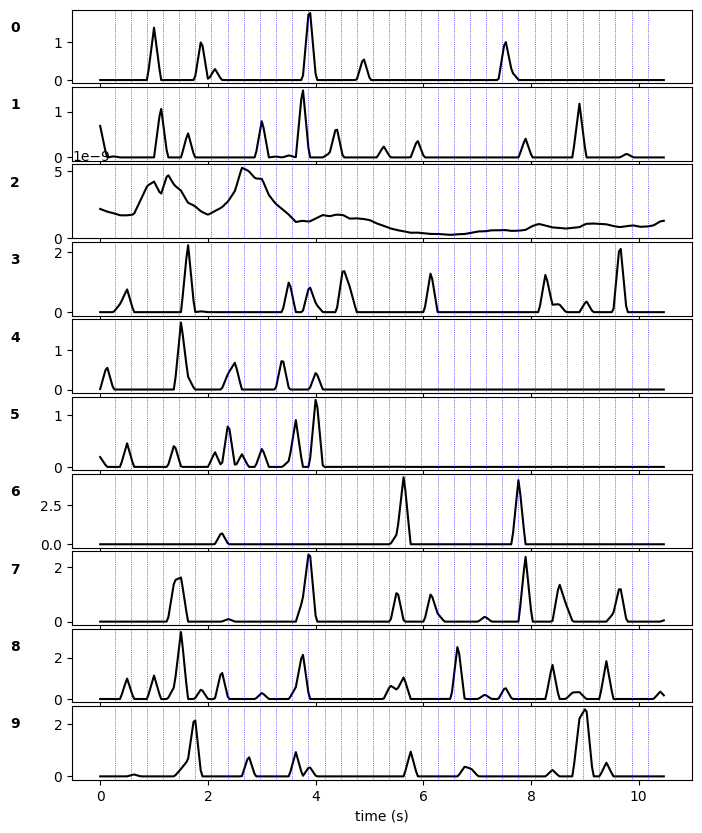

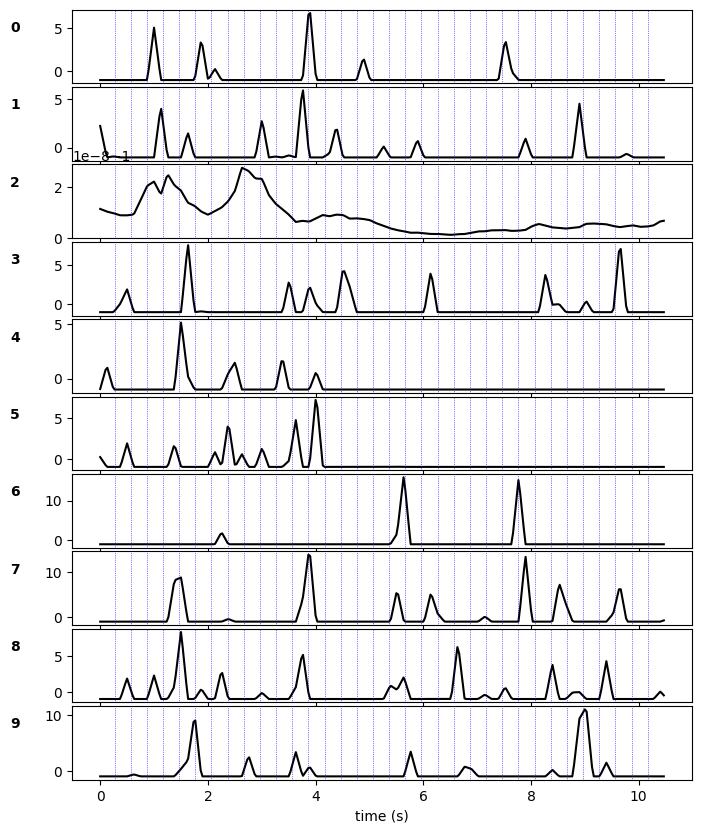

In [50]:
# plot responses
idx_neurosn_to_plot = np.arange(0,10)
h = response.plot_responses(idx_neurosn_to_plot,normalization='by_std', plot_segments=True)
h = response.plot_responses(idx_neurosn_to_plot,normalization='by_mean', plot_segments=True)

## Class `Neurons`

The `Neurons` class stores and handles neuron metadata.
For a `DataSet` object, it is available in `DataSet.info[recording]['neurons']`.
For `Response` objects, it is available in `Response.neurons`.

In [51]:
# neurons = response.neurons
neurons = ds.info["dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce"]['neurons']

In [52]:
# neurons.coord_xyz is a numpy array of size number of neurons x 3 with the xyz coordinates
neurons.coord_xyz.shape

(7495, 3)

In [53]:
# neurons.stats_activity has the descriptive statistics for each neuron
neurons.stats_activity.keys()

dict_keys(['mean_activation', 'std_activation', 'min_activation', 'max_activation'])

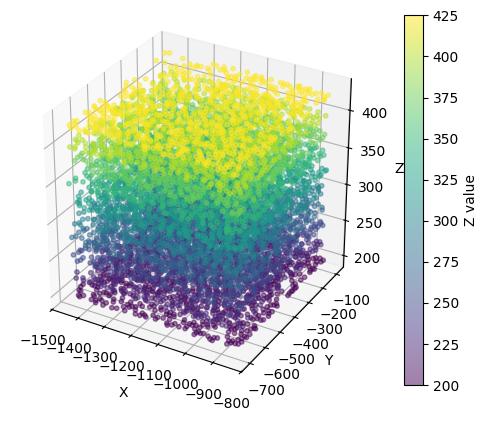

(<Figure size 640x480 with 2 Axes>,
 <Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>)

In [54]:
# plot the cordinates of the neurons
neurons.plot_coordinates()

## Classes for Behavioral Data

### Class `Pupil`
The `Pupil` class handles pupil-size data.

In [55]:
# get the pupil size for trials belonging to one recording and one label
pupils, filtered_trials_df = ds.load_behavior_by(behavior_type='pupil',recording='dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce', label='GaussianDot')
pupil = pupils[0]

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='time (s)', ylabel='pupil size'>)

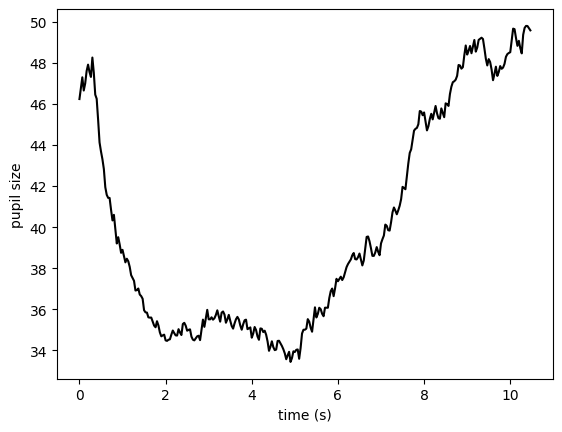

In [56]:
# plo tthe pupil data
pupil.plot()

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='time (s)', ylabel='pupil size'>)

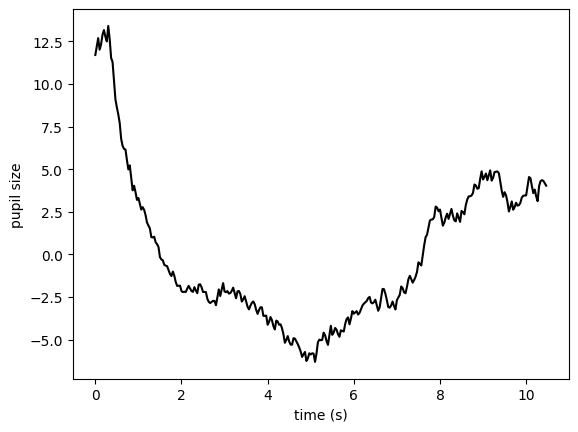

In [57]:
# detrend the pupil data and plot it again
pupil.detrend()
pupil.plot()

## Class `Gaze`
The `Gaze` class handles gaze data.

In [58]:
# get the gaze data for trials belonging to one recording and one label
gazes, filtered_trials_df = ds.load_behavior_by(behavior_type='gaze',recording='dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce', label='GaussianDot')
gaze = gazes[0]

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='gaze x', ylabel='gaze y'>)

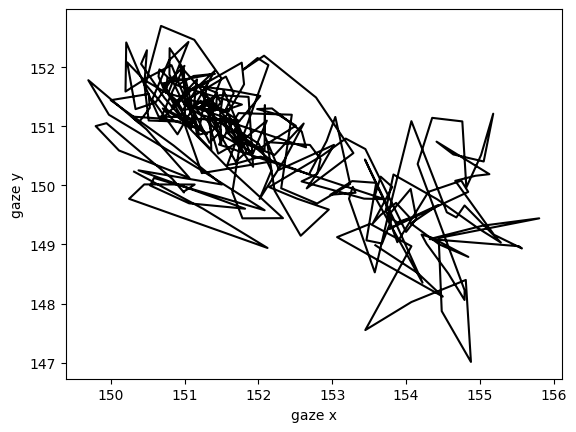

In [59]:
# plot the gaze data
gaze.plot()

## Class `Locomotion`
The `Locomotion` class handles locomotion-speed data.

In [60]:
# get the locomotion data for trials belonging to one recording and one label
locomotions, filtered_trials_df = ds.load_behavior_by(behavior_type='locomotion',recording='dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce', label='GaussianDot')
locomotion = locomotions[0]

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='time (s)', ylabel='locomotion speed'>)

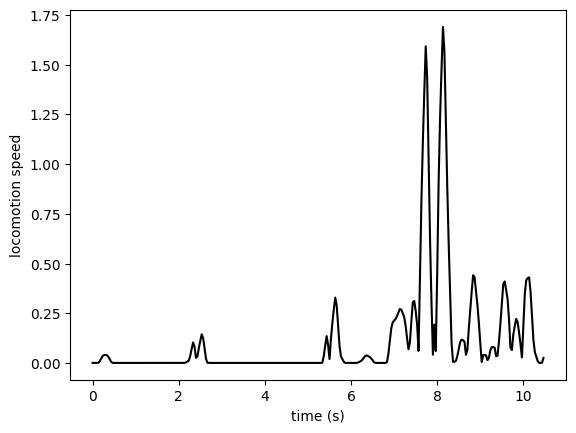

In [61]:
# plot locomotion data
locomotion.plot()